In [101]:

import Kea
from Kea.utils import plotting, data_reader, data_writer
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments, scale_filter
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as patches

import numpy as np

from scipy.signal import windows

import itertools

import h5py

import os

twopi = 2.*np.pi

D = 2
N = 1024
L = N#twopi
dk = twopi/L
dx = L/N

grid_dims = (N, N)
phys_dims = (L, L)

DATA_DIR = '/home/m/Documents/science_codes/Kea/SF_paper/FBM_PSF/'
NAME_PREFIX = DATA_DIR + 'field'

kmin = dk
kmax = np.pi*N/L

b1 = 1.
b2 = 2.

a1 = b1 + D - 1.
a2 = b2 + D - 1.

kb = kmax/10.

# field1 = fbm.create_fbm(grid_dims, phys_dims, (-a1, -a1), gfunc='smooth_pow', func_kwargs={'breaks': (kb,)}, A=1.)
# field12 = fbm.create_fbm(grid_dims, phys_dims, (-a1, -a2), gfunc='smooth_pow', func_kwargs={'breaks': (kb,)}, A=1.)

# file1 = h5py.File('field_1.h5', 'a')
# file1.create_dataset('T.Fr', data=field1)
# file1.close()
# field1 = None

# file12 = h5py.File('field_12.h5', 'a')
# file12.create_dataset('T.Fr', data=field12)
# file12.close()
# field12 = None

file1 = h5py.File('field_1.h5', 'r')
field1 = np.array(file1['T.Fr'][:])
file1.close()

file12 = h5py.File('field_12.h5', 'r')
field12 = np.array(file12['T.Fr'][:])
file12.close()


In [102]:
def get_spectra(field):
    kD, fekD = per_spectra.modal_spectrum(field, phys_dims=phys_dims)
    fekD = fekD * (dk/twopi)**D
    ko, feko, w = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
    kb, fekb, _ = statistics_base.bin_data(
        ko, feko, bin_func=np.nanmean,
        bin_loc='true_center', log_space=True, min_bin=np.nanmin(ko), max_bin=np.nanmax(ko),
        num_bins=24)
    return kb, fekb

In [103]:
kb1, fekb1 = get_spectra(field1)
kb12, fekb12 = get_spectra(field12)

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))


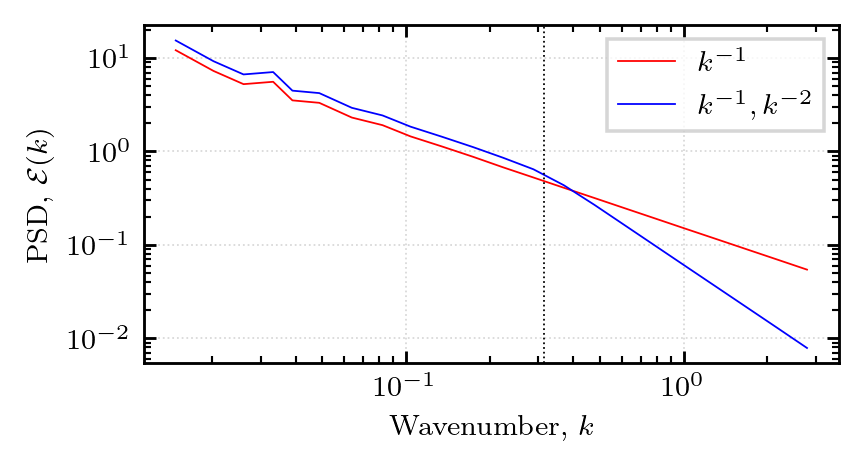

In [104]:

fig, ax = plt.subplots(1, 1, dpi=256, figsize=(3.5, 1.75))

ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='red')
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='blue')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
ax.set_xlabel(r'Wavenumber, $k$')
ax.legend(fancybox=False)

ax.axvline(kb, linewidth=0.5, linestyle=':', color='black')


In [105]:

gtr_FWHM = (1./kb)*2.
eq_FWHM = (1./kb)
less_FWHM = (1./kb)/2.

to_FWHM = np.sqrt(8.*np.log(2.))

def make_psf(field):
    psf_gtr = scale_filter.gaussian_scale_greater(field, gtr_FWHM/dx/to_FWHM)
    psf_eq = scale_filter.gaussian_scale_greater(field, eq_FWHM/dx/to_FWHM)
    psf_less = scale_filter.gaussian_scale_greater(field, less_FWHM/dx/to_FWHM)

    gtr = get_spectra(psf_gtr)
    eq = get_spectra(psf_eq)
    less = get_spectra(psf_less)

    return less, eq, gtr

l1, e1, g1 = make_psf(field1)
l12, e12, g12 = make_psf(field12)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_m

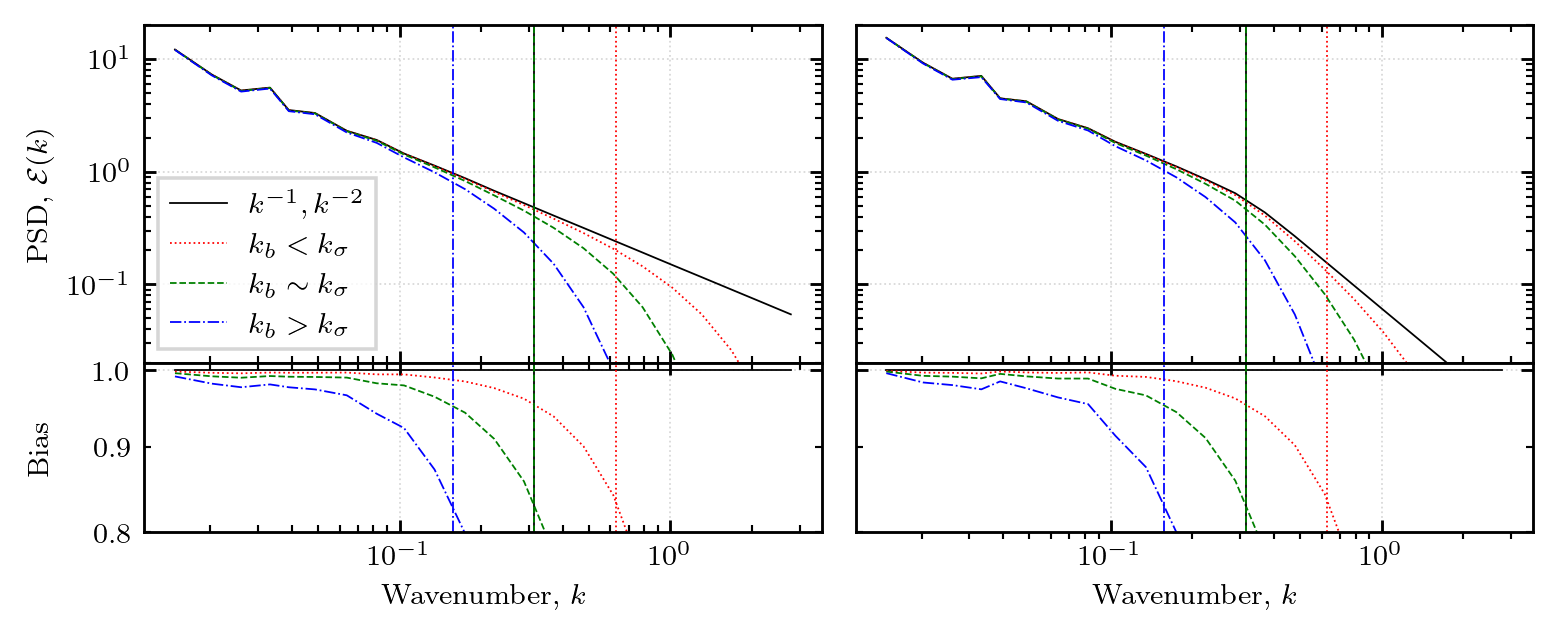

In [106]:

fig = plt.figure(dpi=256, figsize=(7., 2.625))
gs = mpl.gridspec.GridSpec(2, 2, height_ratios=[1, 0.5], figure=fig, hspace=0., wspace=0.05)
axs = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[1,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[1,1])]

ax = axs[0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='black')
ax.plot(l1[0], l1[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='red')
ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='green')
ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='blue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
ax.legend(fancybox=False)
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='red')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='green')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-.', color='blue')
ax.set_ylim((2e-2, 2e1))

ax = axs[1]
ax.plot(kb1, fekb1/fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='black')
ax.plot(l1[0], l1[1]/fekb1, linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='red')
ax.plot(e1[0], e1[1]/fekb1, linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='green')
ax.plot(g1[0], g1[1]/fekb1, linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='blue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_ylabel(r'Bias')
ax.set_xlabel(r'Wavenumber, $k$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='red')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='green')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-.', color='blue')
ax.set_ylim((8e-1, 1.01e0))
ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_minor_formatter(mpl.ticker.FormatStrFormatter('%.1f'))

ax = axs[2]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='black')
ax.plot(l12[0], l12[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='red')
ax.plot(e12[0], e12[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='green')
ax.plot(g12[0], g12[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='blue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.legend(fancybox=False)
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='red')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='green')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-.', color='blue')
ax.set_ylim((2e-2, 2e1))
ax.set_yticklabels([])

ax = axs[3]
ax.plot(kb12, fekb12/fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='black')
ax.plot(l12[0], l12[1]/fekb12, linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='red')
ax.plot(e12[0], e12[1]/fekb12, linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='green')
ax.plot(g12[0], g12[1]/fekb12, linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='blue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
#ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_xlabel(r'Wavenumber, $k$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='red')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='green')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-.', color='blue')
ax.set_ylim((8e-1, 1.01e0))
ax.set_yticklabels([])
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

fig.align_ylabels()


In [107]:

def calc_sf(sf, grid_dims, phys_dims, num_bins=32, log_space=True):
    N = grid_dims[0]
    L = phys_dims[0]
    dx = L/N
    lvm_f = statfunc_base.get_lagvec_magnitude_array([n for n in grid_dims]) * dx

    l_f2, sf2_f2, w_f2 = statistics_base.bin_data(
        lvm_f, sf, bin_func=np.nanmean,
        cut_excess=True, nan_small=False,
        min_bin=dx, max_bin=L/2., num_bins=N//2,
        bin_loc='center', log_space=True)

    l_f2_t = l_f2[np.isfinite(sf2_f2)]
    sf2_f2_t = sf2_f2[np.isfinite(sf2_f2)]
    sf2_f2 = strfn_spectra.interpolate(l_f2_t, sf2_f2_t, l_f2)

    l_b, sf2_b, _ = statistics_base.bin_data(
        l_f2, sf2_f2, bin_func=np.nanmean,
        bin_loc='true_center', log_space=log_space, min_bin=dx, max_bin=L/2.,
        num_bins=num_bins)

    return (l_f2, sf2_f2), (l_b, sf2_b)

sf2_1_eq = np.load('sf2_1_eq.npy')
sf1e, sf1eb = calc_sf(sf2_1_eq, grid_dims, phys_dims)
sf2_1_gtr = np.load('sf2_1_gtr.npy')
sf1g, sf1gb = calc_sf(sf2_1_gtr, grid_dims, phys_dims)
sf2_1_less = np.load('sf2_1_less.npy')
sf1l, sf1lb = calc_sf(sf2_1_less, grid_dims, phys_dims)
sf2_1_none = np.load('sf2_1_none.npy')
sf1n, sf1nb = calc_sf(sf2_1_none, grid_dims, phys_dims)

sf2_12_eq = np.load('sf2_12_eq.npy')
sf12e, sf12eb = calc_sf(sf2_12_eq, grid_dims, phys_dims)
sf2_12_gtr = np.load('sf2_12_gtr.npy')
sf12g, sf12gb = calc_sf(sf2_12_gtr, grid_dims, phys_dims)
sf2_12_less = np.load('sf2_12_less.npy')
sf12l, sf12lb = calc_sf(sf2_12_less, grid_dims, phys_dims)
sf2_12_none = np.load('sf2_12_none.npy')
sf12n, sf12nb = calc_sf(sf2_12_none, grid_dims, phys_dims)


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_m

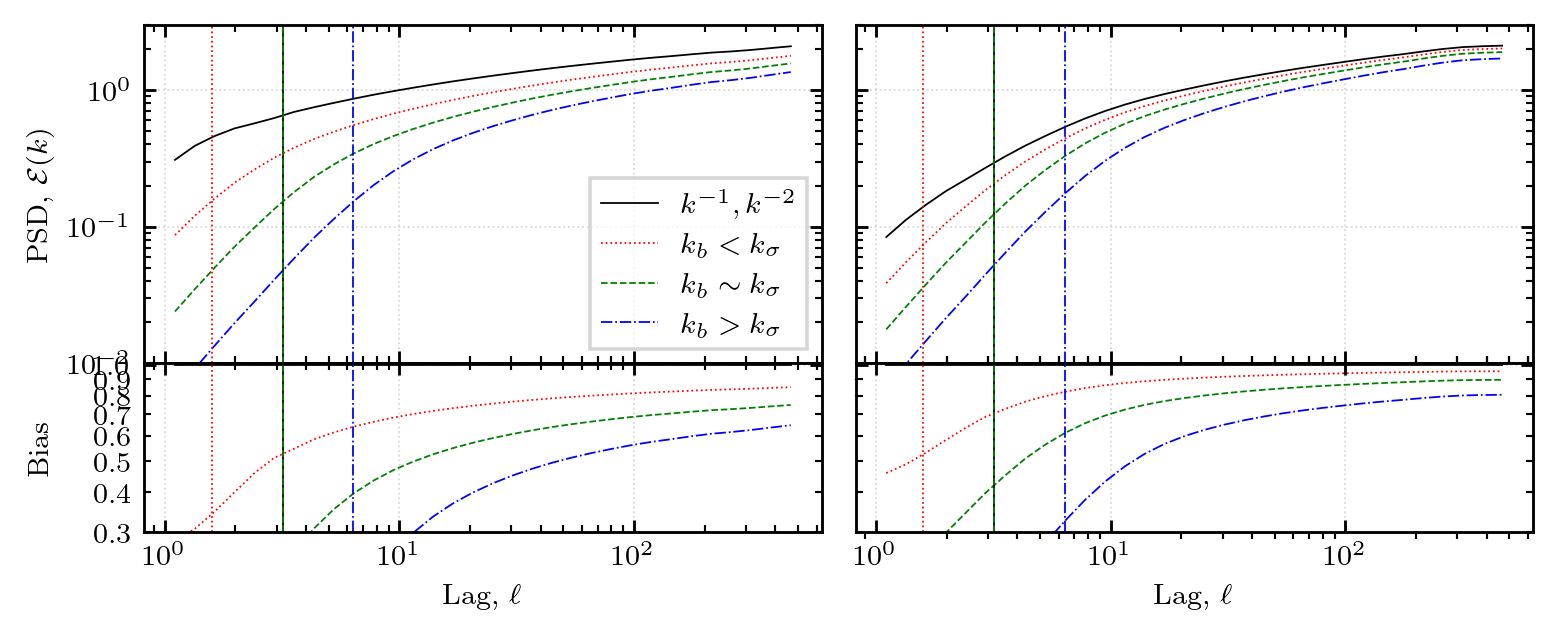

In [108]:

fig = plt.figure(dpi=256, figsize=(7., 2.625))
gs = mpl.gridspec.GridSpec(2, 2, height_ratios=[1, 0.5], figure=fig, hspace=0., wspace=0.05)
axs = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[1,0]), fig.add_subplot(gs[0,1]), fig.add_subplot(gs[1,1])]

ax = axs[0]
ax.plot(sf1nb[0], sf1nb[1], linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='black')
ax.plot(sf1lb[0], sf1lb[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='red')
ax.plot(sf1eb[0], sf1eb[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='green')
ax.plot(sf1gb[0], sf1gb[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='blue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
ax.legend(fancybox=False)
ax.axvline(1./kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(less_FWHM, linewidth=0.5, linestyle=':', color='red')
ax.axvline(eq_FWHM, linewidth=0.5, linestyle='--', color='green')
ax.axvline(gtr_FWHM, linewidth=0.5, linestyle='-.', color='blue')
ax.set_ylim((1e-2, 3e0))

ax = axs[1]
ax.plot(sf1nb[0], sf1nb[1]/sf1nb[1], linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='black')
ax.plot(sf1lb[0], sf1lb[1]/sf1nb[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='red')
ax.plot(sf1eb[0], sf1eb[1]/sf1nb[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='green')
ax.plot(sf1gb[0], sf1gb[1]/sf1nb[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='blue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_ylabel(r'Bias')
ax.set_xlabel(r'Lag, $\ell$')
ax.axvline(1./kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(less_FWHM, linewidth=0.5, linestyle=':', color='red')
ax.axvline(eq_FWHM, linewidth=0.5, linestyle='--', color='green')
ax.axvline(gtr_FWHM, linewidth=0.5, linestyle='-.', color='blue')
ax.set_ylim((3e-1, 1.01e0))
ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
ax.yaxis.set_minor_formatter(mpl.ticker.FormatStrFormatter('%.1f'))

ax = axs[2]
ax.plot(sf12nb[0], sf12nb[1], linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='black')
ax.plot(sf12lb[0], sf12lb[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='red')
ax.plot(sf12eb[0], sf12eb[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='green')
ax.plot(sf12gb[0], sf12gb[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='blue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.legend(fancybox=False)
ax.axvline(1./kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(less_FWHM, linewidth=0.5, linestyle=':', color='red')
ax.axvline(eq_FWHM, linewidth=0.5, linestyle='--', color='green')
ax.axvline(gtr_FWHM, linewidth=0.5, linestyle='-.', color='blue')
ax.set_ylim((1e-2, 3e0))
ax.set_yticklabels([])

ax = axs[3]
ax.plot(sf12nb[0], sf12nb[1]/sf12nb[1], linestyle='-', linewidth=0.5, label=r'$k^{-1},k^{-2}$', color='black')
ax.plot(sf12lb[0], sf12lb[1]/sf12nb[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='red')
ax.plot(sf12eb[0], sf12eb[1]/sf12nb[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='green')
ax.plot(sf12gb[0], sf12gb[1]/sf12nb[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='blue')
ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
#ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
ax.set_xlabel(r'Lag, $\ell$')
ax.axvline(1./kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(less_FWHM, linewidth=0.5, linestyle=':', color='red')
ax.axvline(eq_FWHM, linewidth=0.5, linestyle='--', color='green')
ax.axvline(gtr_FWHM, linewidth=0.5, linestyle='-.', color='blue')
ax.set_ylim((3e-1, 1.01e0))
ax.set_yticklabels([])
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
#ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

fig.align_ylabels()


In [109]:
import sympy as sp

def omni_spectrum(ko, ell, sf2, phys_dims, grid_dims, a, b):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    kk = kk[::-1]
    fek = fek[::-1]

    return kk, fek

from scipy.interpolate import interp1d
def interpolate(x, y, x_interp):
    f_int = interp1d(np.log10(x), y, kind='linear', fill_value='extrapolate')
    fek_new = f_int(np.log10(x_interp))
    return fek_new

def get_powerlaw(k, fek, num_bins=16, log_space=False):
    est_alpha = np.gradient(np.log(fek), np.log(k))
    if num_bins is None:
        return est_alpha
    b_k, b_est_alpha, _ = statistics_base.bin_data(
        k, est_alpha, bin_func=np.nanmean, log_space=log_space,
        bin_loc='left', num_bins=num_bins, min_bin=np.nanmin(k), max_bin=np.nanmax(k),
        ignore_nan=True)
    est_alpha = interpolate(b_k, b_est_alpha, k)
    return est_alpha

def debias(est_alpha, b, D):
    sp_beta = sp.symbols('beta', positive=True, real=True)
    sp_D = sp.symbols('D', positive=True, real=True)
    sp_b = sp.symbols('b', positive=True, real=True)
    spec_bias = sp.S(2)*sp.S(2)**(-sp_beta) * sp_b**(sp_beta - sp.S(1)) * (sp.gamma(sp_D/sp.S(2)) * sp.gamma((sp.S(3) - sp_beta) / sp.S(2))/sp.gamma(sp_D/sp.S(2) + sp_beta/sp.S(2) - sp.Rational(1,2)))
    spec_bias = spec_bias.subs({sp_D: sp.S(D), sp_b: sp.S(b)})

    #bias_factor = np.zeros_like(est_alpha)
    est_alpha[est_alpha > -1.01] = -1.01
    est_alpha[est_alpha < -2.99] = -2.99

    f_bias = sp.lambdify(sp_beta, spec_bias)
    bias_factor = np.float64(f_bias(-est_alpha))

    #for i, _a in enumerate(est_alpha):
    #    bias_factor[i] = np.float64(f_bias())

    return bias_factor


In [110]:

def get_3_specs(ko, sf):
    _kb1, _fekb1 = omni_spectrum(ko, sf[0], sf[1], phys_dims, grid_dims, 1., 1.)
    _kb2, _fekb2 = omni_spectrum(ko, sf[0], sf[1], phys_dims, grid_dims, np.sqrt(2.), np.sqrt(2.))
    _kb3, _fekb3 = omni_spectrum(ko, sf[0], sf[1], phys_dims, grid_dims, 2., 2.)
    return (_kb1, _fekb1), (_kb2, _fekb2), (_kb3, _fekb3)

## Get equiv-spectrum
# Need 12 equiv-spectra per field.
fek1nb1, fek1nb2, fek1nb3 = get_3_specs(kb1, sf1nb)
fek1lb1, fek1lb2, fek1lb3 = get_3_specs(kb1, sf1lb)
fek1eb1, fek1eb2, fek1eb3 = get_3_specs(kb1, sf1eb)
fek1gb1, fek1gb2, fek1gb3 = get_3_specs(kb1, sf1gb)

fek12nb1, fek12nb2, fek12nb3 = get_3_specs(kb12, sf12nb)
fek12lb1, fek12lb2, fek12lb3 = get_3_specs(kb12, sf12lb)
fek12eb1, fek12eb2, fek12eb3 = get_3_specs(kb12, sf12eb)
fek12gb1, fek12gb2, fek12gb3 = get_3_specs(kb12, sf12gb)


(0.01, 3.0)

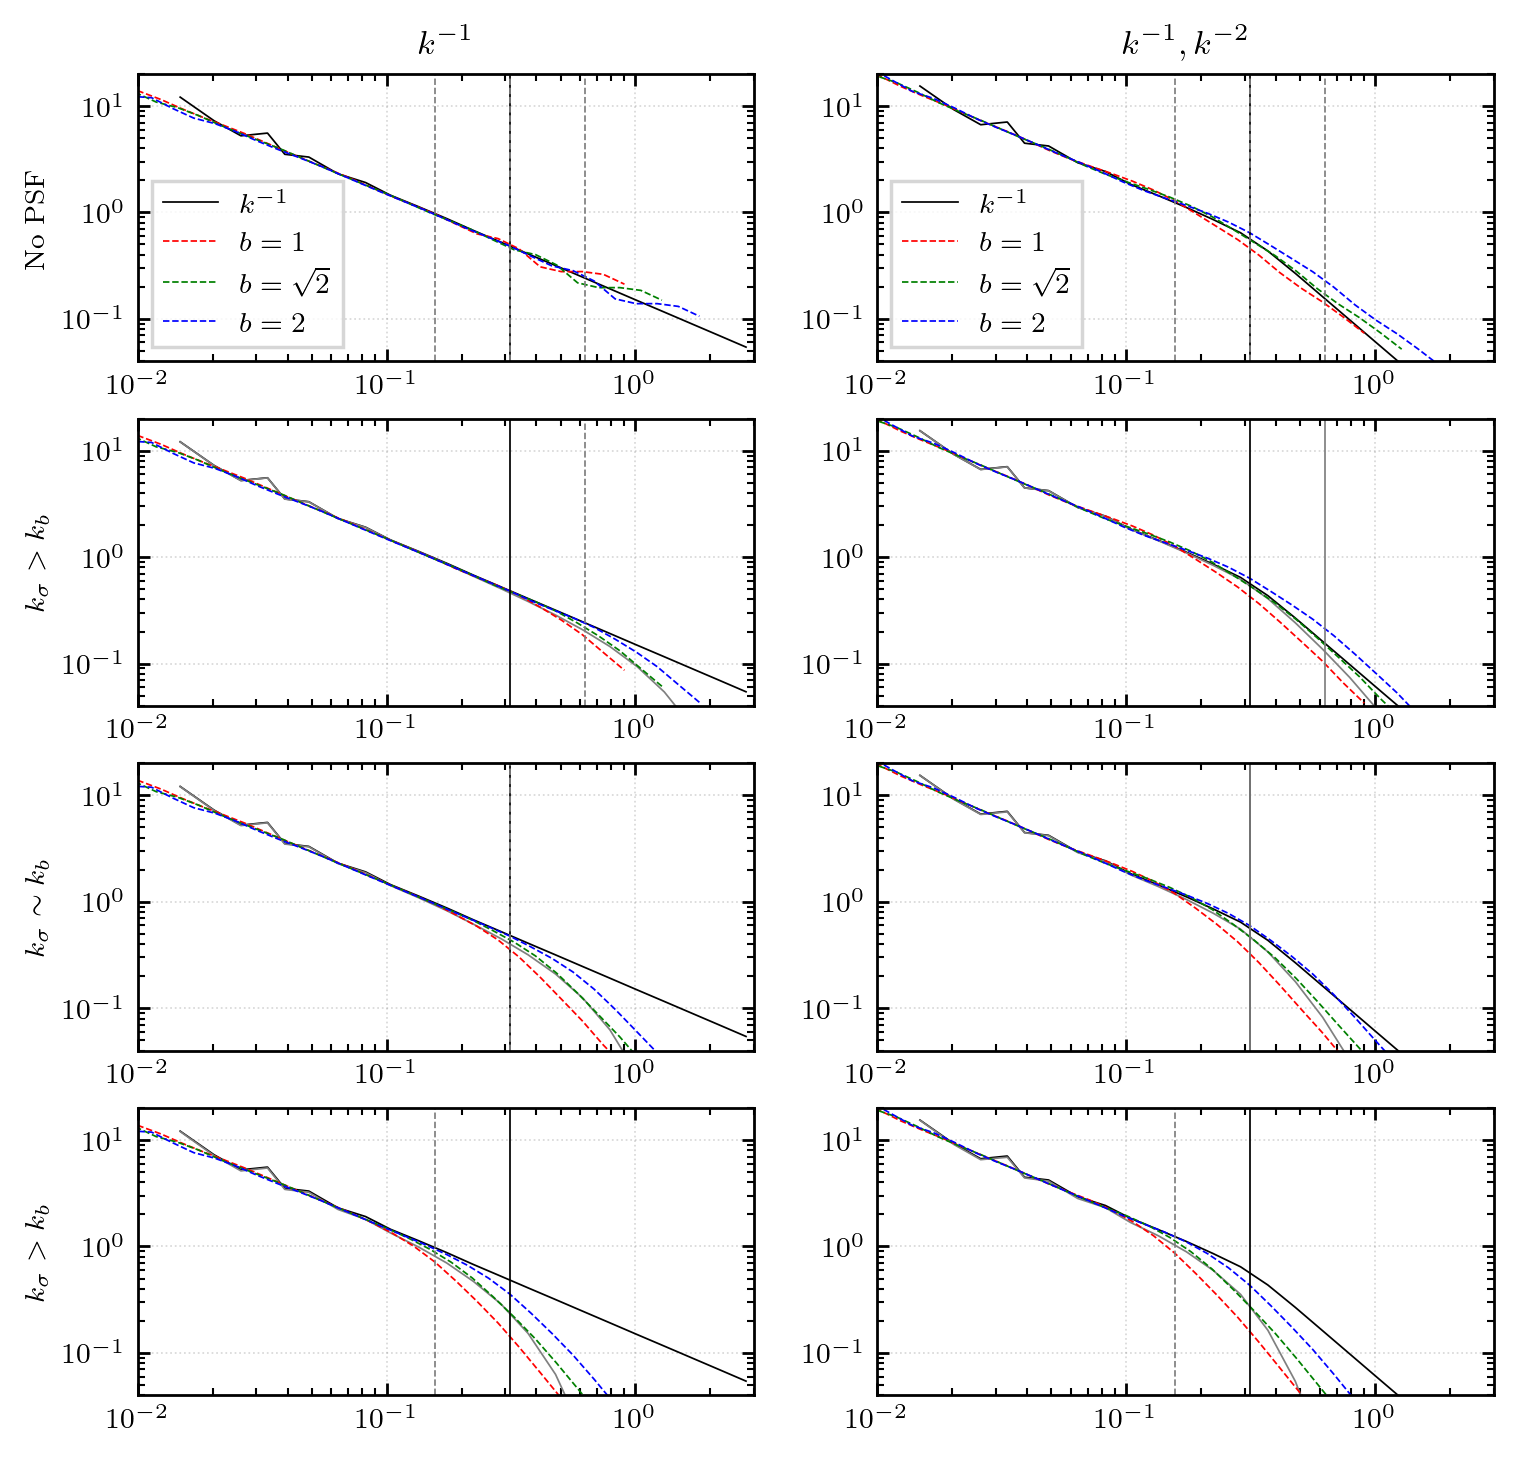

In [150]:

fig, axs = plt.subplots(4, 2, figsize=(2.*3.5, 4.*1.75))

ax = axs[0,0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
#ax.plot(l1[0], l1[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek1nb1[0], fek1nb1[1], linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1nb2[0], fek1nb2[1], linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1nb3[0], fek1nb3[1], linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'No PSF')
ax.legend(fancybox=False)
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))
ax.set_title(r'$k^{-1}$')

ax = axs[1,0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(l1[0], l1[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek1lb1[0], fek1lb1[1], linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1lb2[0], fek1lb2[1], linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1lb3[0], fek1lb3[1], linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma} > k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


ax = axs[2,0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(e1[0], e1[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek1eb1[0], fek1eb1[1], linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1eb2[0], fek1eb2[1], linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1eb3[0], fek1eb3[1], linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma} \sim k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


ax = axs[3,0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(g1[0], g1[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek1gb1[0], fek1gb1[1], linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1gb2[0], fek1gb2[1], linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1gb3[0], fek1gb3[1], linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma}>k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))

##


ax = axs[0,1]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
#ax.plot(l1[0], l1[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek12nb1[0], fek12nb1[1], linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12nb2[0], fek12nb2[1], linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12nb3[0], fek12nb3[1], linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.set_ylabel(r'No PSF')
ax.legend(fancybox=False)
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))
ax.set_title(r'$k^{-1},k^{-2}$')

ax = axs[1,1]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(l12[0], l12[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek12lb1[0], fek12lb1[1], linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12lb2[0], fek12lb2[1], linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12lb3[0], fek12lb3[1], linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.set_ylabel(r'$k_{\sigma} > k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='-', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


ax = axs[2,1]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(e12[0], e12[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek12eb1[0], fek12eb1[1], linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12eb2[0], fek12eb2[1], linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12eb3[0], fek12eb3[1], linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.set_ylabel(r'$k_{\sigma} \sim k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='-', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


ax = axs[3,1]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(g12[0], g12[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek12gb1[0], fek12gb1[1], linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12gb2[0], fek12gb2[1], linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12gb3[0], fek12gb3[1], linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.set_ylabel(r'$k_{\sigma}>k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


In [144]:

def get_powerlaws(b1, b2, b3):
    a_fekb1 = get_powerlaw(b1[0], b1[1], log_space=True, num_bins=16)
    a_fekb2 = get_powerlaw(b2[0], b2[1], log_space=True, num_bins=16)
    a_fekb3 = get_powerlaw(b3[0], b3[1], log_space=True, num_bins=16)
    return a_fekb1, a_fekb2, a_fekb3

a_fekb1 = get_powerlaw(kb1, fekb1, log_space=False, num_bins=None)
a_l1 = get_powerlaw(l1[0], l1[1], log_space=False, num_bins=None)
a_e1 = get_powerlaw(e1[0], e1[1], log_space=False, num_bins=None)
a_g1 = get_powerlaw(g1[0], g1[1], log_space=False, num_bins=None)

a_fek1nb1, a_fek1nb2, a_fek1nb3 = get_powerlaws(fek1nb1, fek1nb2, fek1nb3)
a_fek1lb1, a_fek1lb2, a_fek1lb3 = get_powerlaws(fek1lb1, fek1lb2, fek1lb3)
a_fek1eb1, a_fek1eb2, a_fek1eb3 = get_powerlaws(fek1eb1, fek1eb2, fek1eb3)
a_fek1gb1, a_fek1gb2, a_fek1gb3 = get_powerlaws(fek1gb1, fek1gb2, fek1gb3)

a_fekb12 = get_powerlaw(kb12, fekb12, log_space=False, num_bins=None)
a_l12 = get_powerlaw(l12[0], l12[1], log_space=False, num_bins=None)
a_e12 = get_powerlaw(e12[0], e12[1], log_space=False, num_bins=None)
a_g12 = get_powerlaw(g12[0], g12[1], log_space=False, num_bins=None)

a_fek12nb1, a_fek12nb2, a_fek12nb3 = get_powerlaws(fek12nb1, fek12nb2, fek12nb3)
a_fek12lb1, a_fek12lb2, a_fek12lb3 = get_powerlaws(fek12lb1, fek12lb2, fek12lb3)
a_fek12eb1, a_fek12eb2, a_fek12eb3 = get_powerlaws(fek12eb1, fek12eb2, fek12eb3)
a_fek12gb1, a_fek12gb2, a_fek12gb3 = get_powerlaws(fek12gb1, fek12gb2, fek12gb3)

def get_debias(b1, b2, b3):
    b_b1 = debias(b1, 1., len(grid_dims))
    b_b2 = debias(b2, np.sqrt(2.), len(grid_dims))
    b_b3 = debias(b3, 2., len(grid_dims))
    return b_b1, b_b2, b_b3

b_fek1nb1, b_fek1nb2, b_fek1nb3 = get_debias(a_fek1nb1, a_fek1nb2, a_fek1nb3)
b_fek1lb1, b_fek1lb2, b_fek1lb3 = get_debias(a_fek1lb1, a_fek1lb2, a_fek1lb3)
b_fek1eb1, b_fek1eb2, b_fek1eb3 = get_debias(a_fek1eb1, a_fek1eb2, a_fek1eb3)
b_fek1gb1, b_fek1gb2, b_fek1gb3 = get_debias(a_fek1gb1, a_fek1gb2, a_fek1gb3)

b_fek12nb1, b_fek12nb2, b_fek12nb3 = get_debias(a_fek12nb1, a_fek12nb2, a_fek12nb3)
b_fek12lb1, b_fek12lb2, b_fek12lb3 = get_debias(a_fek12lb1, a_fek12lb2, a_fek12lb3)
b_fek12eb1, b_fek12eb2, b_fek12eb3 = get_debias(a_fek12eb1, a_fek12eb2, a_fek12eb3)
b_fek12gb1, b_fek12gb2, b_fek12gb3 = get_debias(a_fek12gb1, a_fek12gb2, a_fek12gb3)


(0.01, 3.0)

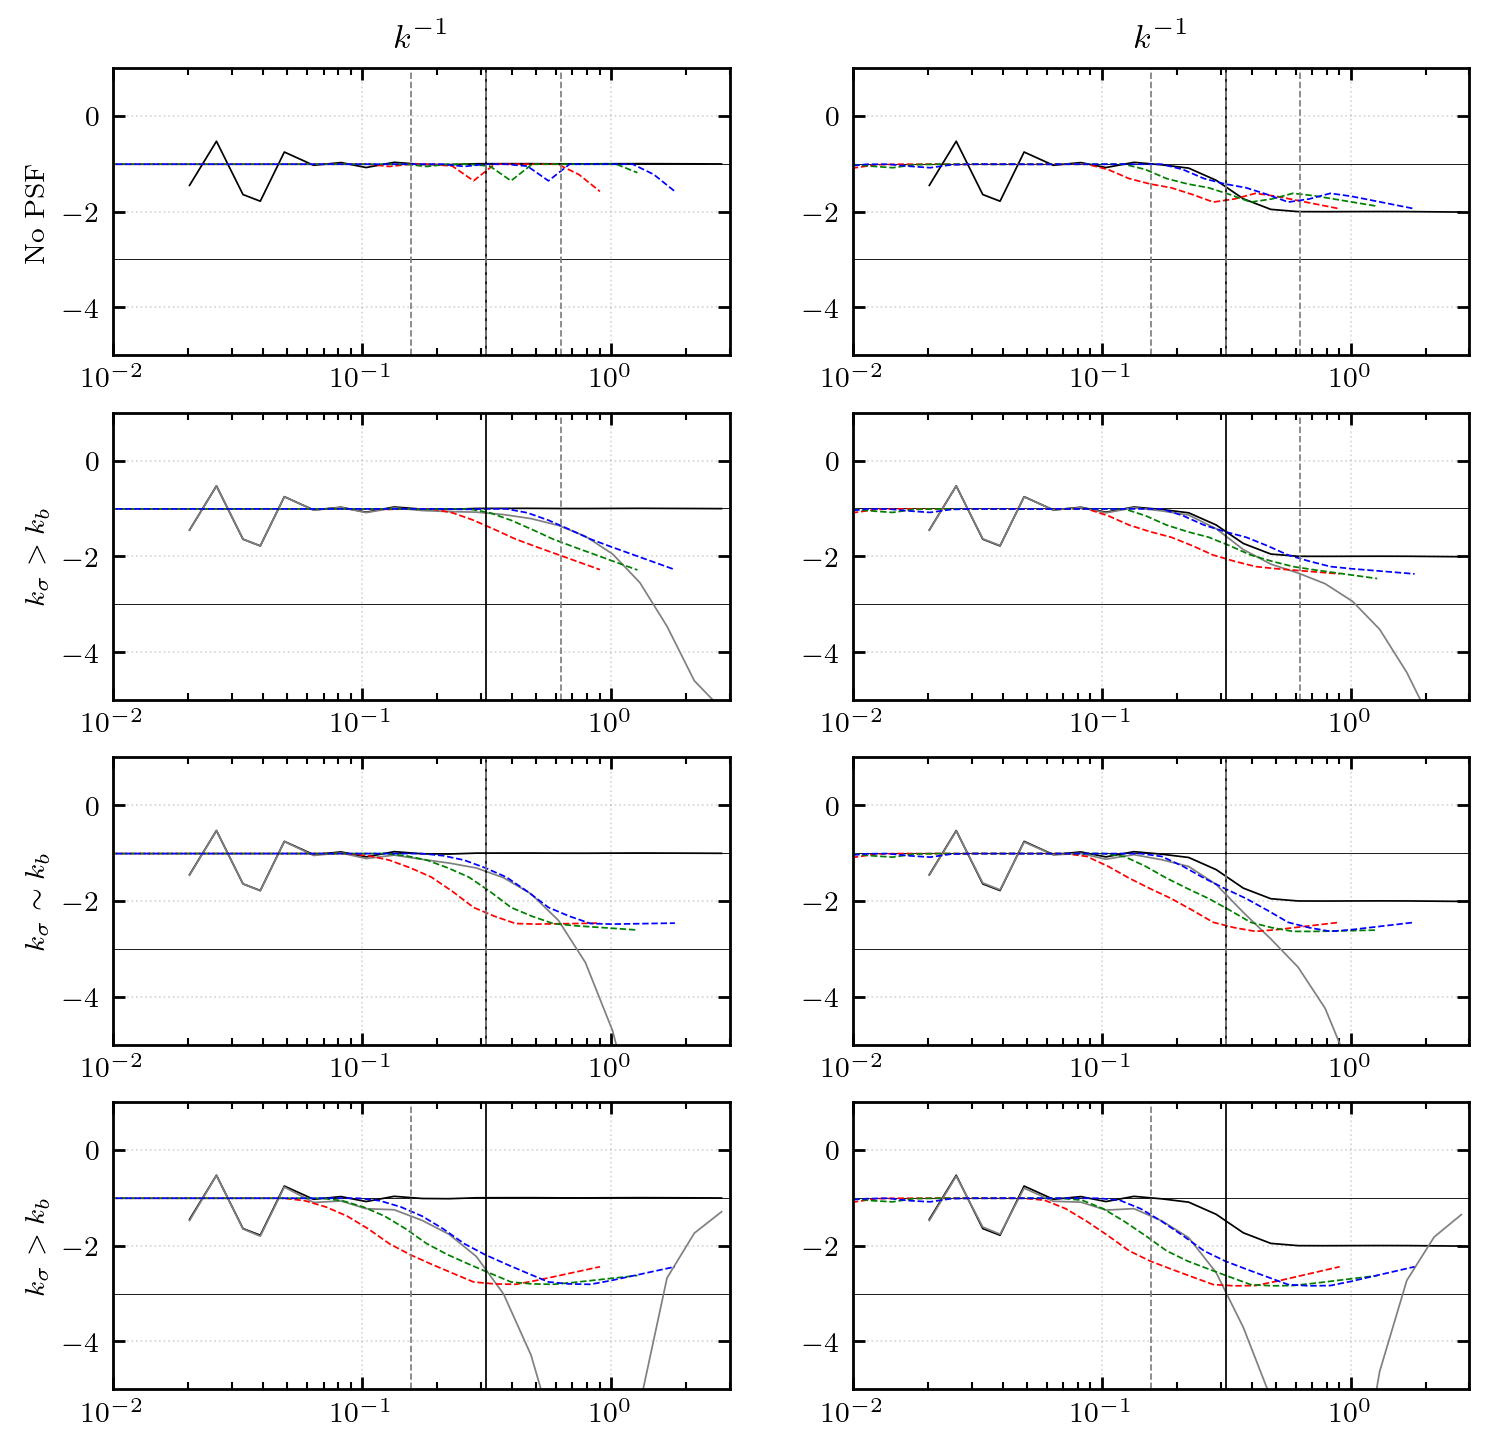

In [152]:

fig, axs = plt.subplots(4, 2, figsize=(2.*3.5, 4.*1.75))

ax = axs[0,0]
ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(kb1, a_fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(fek1nb1[0], a_fek1nb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1nb2[0], a_fek1nb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1nb3[0], a_fek1nb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'No PSF')
#ax.legend(fancybox=False)
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((-5, 1))
ax.set_xlim((1e-2, 3e0))
ax.set_title(r'$k^{-1}$')

ax = axs[1,0]
ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(kb1, a_fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(l1[0], a_l1, linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
ax.plot(fek1lb1[0], a_fek1lb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1lb2[0], a_fek1lb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1lb3[0], a_fek1lb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma} > k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((-5, 1))
ax.set_xlim((1e-2, 3e0))

ax = axs[2,0]
ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(kb1, a_fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(e1[0], a_e1, linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
ax.plot(fek1eb1[0], a_fek1eb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1eb2[0], a_fek1eb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1eb3[0], a_fek1eb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma} \sim k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((-5, 1))
ax.set_xlim((1e-2, 3e0))


ax = axs[3,0]
ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(kb1, a_fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(g1[0], a_g1, linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
ax.plot(fek1gb1[0], a_fek1gb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1gb2[0], a_fek1gb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1gb3[0], a_fek1gb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma}>k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((-5, 1))
ax.set_xlim((1e-2, 3e0))



ax = axs[0,1]
ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(kb12, a_fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(fek12nb1[0], a_fek12nb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12nb2[0], a_fek12nb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12nb3[0], a_fek12nb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.legend(fancybox=False)
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((-5, 1))
ax.set_xlim((1e-2, 3e0))
ax.set_title(r'$k^{-1}$')

ax = axs[1,1]
ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(kb12, a_fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(l12[0], a_l12, linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
ax.plot(fek12lb1[0], a_fek12lb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12lb2[0], a_fek12lb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12lb3[0], a_fek12lb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((-5, 1))
ax.set_xlim((1e-2, 3e0))

ax = axs[2,1]
ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(kb12, a_fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(e12[0], a_e12, linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
ax.plot(fek12eb1[0], a_fek12eb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12eb2[0], a_fek12eb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12eb3[0], a_fek12eb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((-5, 1))
ax.set_xlim((1e-2, 3e0))


ax = axs[3,1]
ax.axhline(-1, color='black', linestyle='-', linewidth=0.25)
ax.axhline(-3, color='black', linestyle='-', linewidth=0.25)

ax.plot(kb12, a_fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(g12[0], a_g12, linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
ax.plot(fek12gb1[0], a_fek12gb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12gb2[0], a_fek12gb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12gb3[0], a_fek12gb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((-5, 1))
ax.set_xlim((1e-2, 3e0))


(0.01, 3.0)

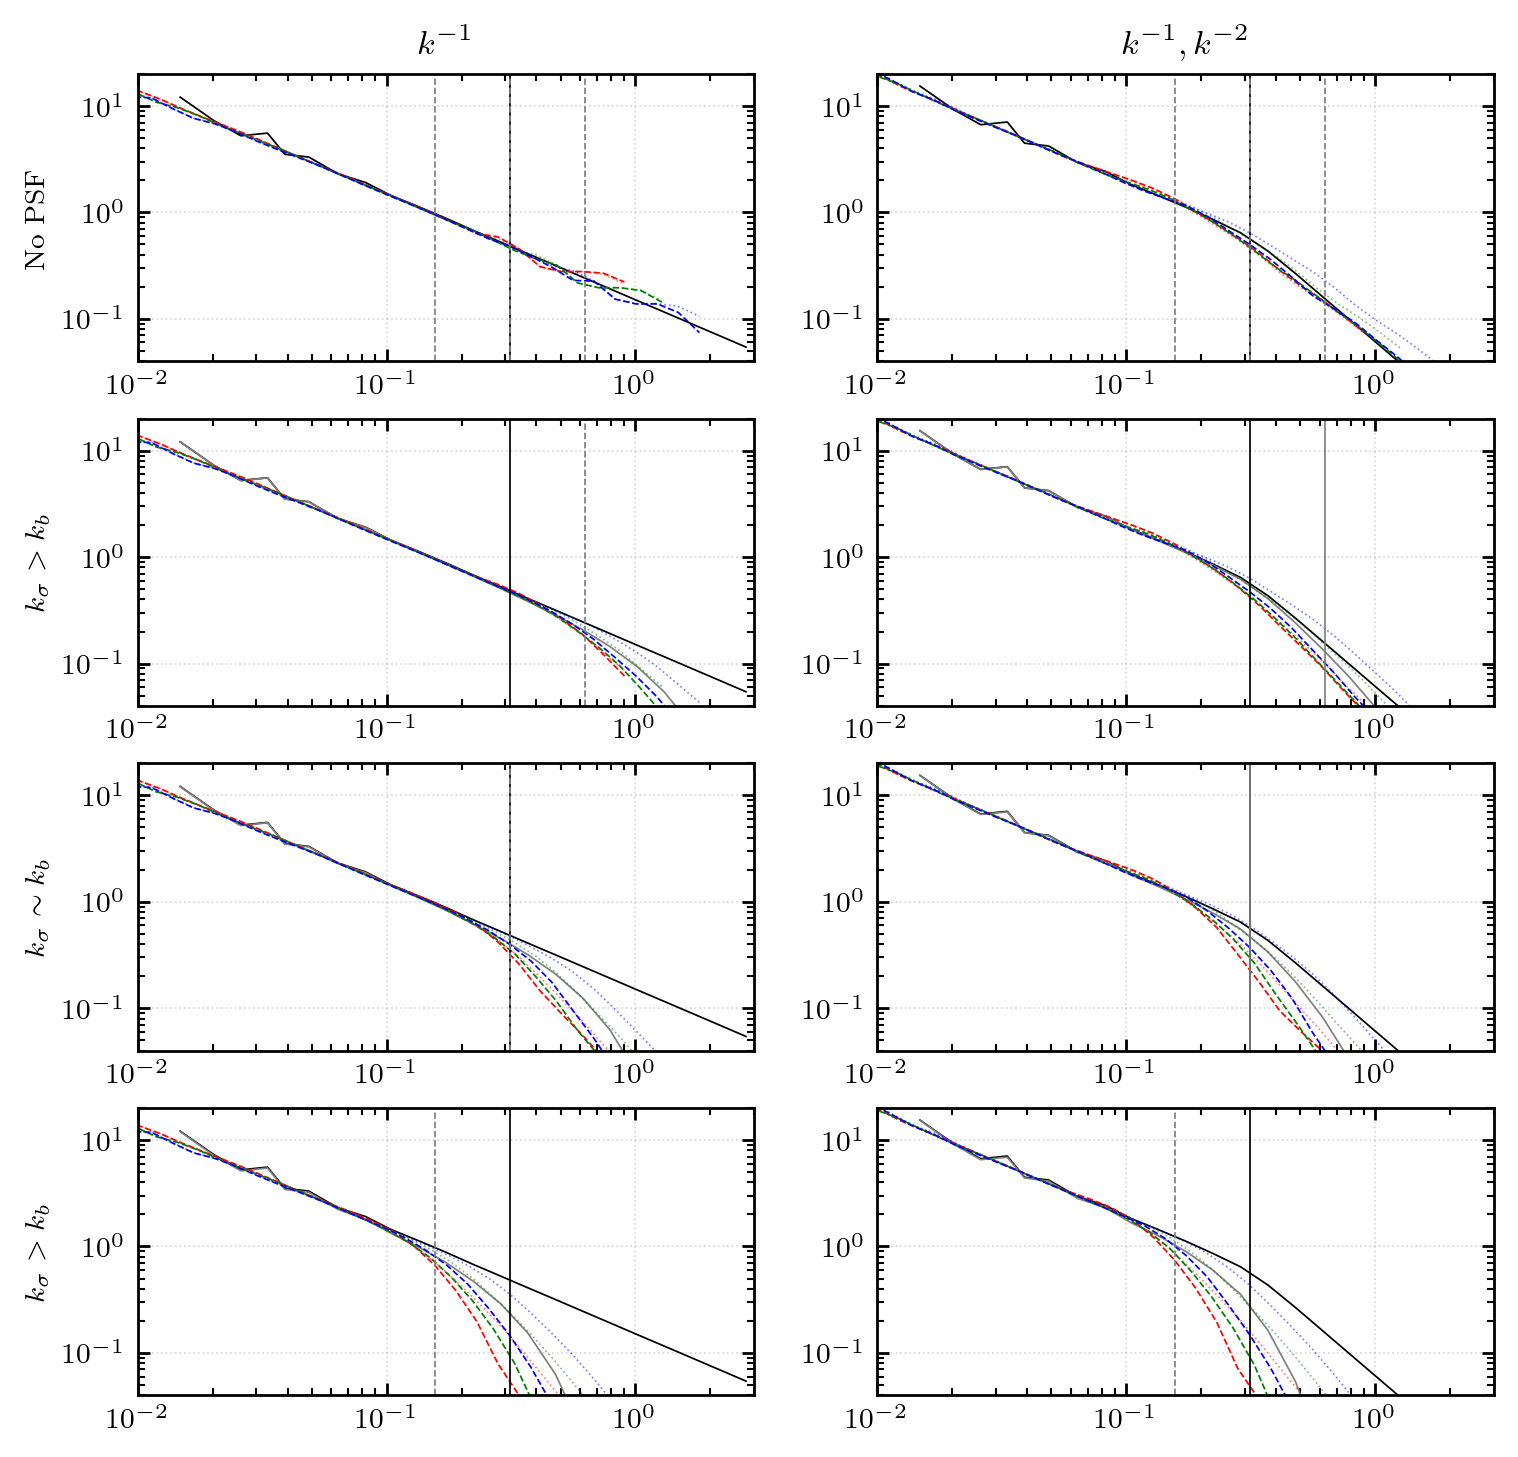

In [158]:

fig, axs = plt.subplots(4, 2, figsize=(2.*3.5, 4.*1.75))

ax = axs[0,0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
#ax.plot(l1[0], l1[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek1nb1[0], fek1nb1[1], linestyle=':', linewidth=0.5, color='red', label=r'$b=1$', alpha=0.5)
ax.plot(fek1nb2[0], fek1nb2[1], linestyle=':', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$', alpha=0.5)
ax.plot(fek1nb3[0], fek1nb3[1], linestyle=':', linewidth=0.5, color='blue', label=r'$b=2$', alpha=0.5)

ax.plot(fek1nb1[0], fek1nb1[1]/b_fek1nb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1nb2[0], fek1nb2[1]/b_fek1nb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1nb3[0], fek1nb3[1]/b_fek1nb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'No PSF')
#ax.legend(fancybox=False)
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))
ax.set_title(r'$k^{-1}$')

ax = axs[1,0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(l1[0], l1[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek1lb1[0], fek1lb1[1], linestyle=':', linewidth=0.5, color='red', label=r'$b=1$', alpha=0.5)
ax.plot(fek1lb2[0], fek1lb2[1], linestyle=':', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$', alpha=0.5)
ax.plot(fek1lb3[0], fek1lb3[1], linestyle=':', linewidth=0.5, color='blue', label=r'$b=2$', alpha=0.5)

ax.plot(fek1lb1[0], fek1lb1[1]/b_fek1lb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1lb2[0], fek1lb2[1]/b_fek1lb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1lb3[0], fek1lb3[1]/b_fek1lb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma} > k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


ax = axs[2,0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(e1[0], e1[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')


ax.plot(fek1eb1[0], fek1eb1[1], linestyle=':', linewidth=0.5, color='red', label=r'$b=1$', alpha=0.5)
ax.plot(fek1eb2[0], fek1eb2[1], linestyle=':', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$', alpha=0.5)
ax.plot(fek1eb3[0], fek1eb3[1], linestyle=':', linewidth=0.5, color='blue', label=r'$b=2$', alpha=0.5)

ax.plot(fek1eb1[0], fek1eb1[1]/b_fek1eb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1eb2[0], fek1eb2[1]/b_fek1eb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1eb3[0], fek1eb3[1]/b_fek1eb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma} \sim k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


ax = axs[3,0]
ax.plot(kb1, fekb1, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(g1[0], g1[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek1gb1[0], fek1gb1[1], linestyle=':', linewidth=0.5, color='red', label=r'$b=1$', alpha=0.5)
ax.plot(fek1gb2[0], fek1gb2[1], linestyle=':', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$', alpha=0.5)
ax.plot(fek1gb3[0], fek1gb3[1], linestyle=':', linewidth=0.5, color='blue', label=r'$b=2$', alpha=0.5)

ax.plot(fek1gb1[0], fek1gb1[1]/b_fek1gb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek1gb2[0], fek1gb2[1]/b_fek1gb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek1gb3[0], fek1gb3[1]/b_fek1gb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
ax.set_ylabel(r'$k_{\sigma}>k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))

##


ax = axs[0,1]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
#ax.plot(l1[0], l1[1], linestyle=':', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek12nb1[0], fek12nb1[1], linestyle=':', linewidth=0.5, color='red', label=r'$b=1$', alpha=0.5)
ax.plot(fek12nb2[0], fek12nb2[1], linestyle=':', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$', alpha=0.5)
ax.plot(fek12nb3[0], fek12nb3[1], linestyle=':', linewidth=0.5, color='blue', label=r'$b=2$', alpha=0.5)

ax.plot(fek12nb1[0], fek12nb1[1]/b_fek12nb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12nb2[0], fek12nb2[1]/b_fek12nb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12nb3[0], fek12nb3[1]/b_fek12nb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.set_ylabel(r'No PSF')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))
ax.set_title(r'$k^{-1},k^{-2}$')

ax = axs[1,1]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(l12[0], l12[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek12lb1[0], fek12lb1[1], linestyle=':', linewidth=0.5, color='red', label=r'$b=1$', alpha=0.5)
ax.plot(fek12lb2[0], fek12lb2[1], linestyle=':', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$', alpha=0.5)
ax.plot(fek12lb3[0], fek12lb3[1], linestyle=':', linewidth=0.5, color='blue', label=r'$b=2$', alpha=0.5)

ax.plot(fek12lb1[0], fek12lb1[1]/b_fek12lb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12lb2[0], fek12lb2[1]/b_fek12lb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12lb3[0], fek12lb3[1]/b_fek12lb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.set_ylabel(r'$k_{\sigma} > k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
ax.axvline(1./less_FWHM, linewidth=0.5, linestyle='-', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


ax = axs[2,1]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(e12[0], e12[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek12eb1[0], fek12eb1[1], linestyle=':', linewidth=0.5, color='red', label=r'$b=1$', alpha=0.5)
ax.plot(fek12eb2[0], fek12eb2[1], linestyle=':', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$', alpha=0.5)
ax.plot(fek12eb3[0], fek12eb3[1], linestyle=':', linewidth=0.5, color='blue', label=r'$b=2$', alpha=0.5)

ax.plot(fek12eb1[0], fek12eb1[1]/b_fek12eb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12eb2[0], fek12eb2[1]/b_fek12eb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12eb3[0], fek12eb3[1]/b_fek12eb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.set_ylabel(r'$k_{\sigma} \sim k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='-', color='gray')
#ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='-', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))


ax = axs[3,1]
ax.plot(kb12, fekb12, linestyle='-', linewidth=0.5, label=r'$k^{-1}$', color='black')
ax.plot(g12[0], g12[1], linestyle='-', linewidth=0.5, label=r'$k_{b} < k_{\sigma}$', color='gray')
#ax.plot(e1[0], e1[1], linestyle='--', linewidth=0.5, label=r'$k_{b}\sim k_{\sigma}$', color='gray')
#ax.plot(g1[0], g1[1], linestyle='-.', linewidth=0.5, label=r'$k_{b} > k_{\sigma}$', color='gray')

ax.plot(fek12gb1[0], fek12gb1[1], linestyle=':', linewidth=0.5, color='red', label=r'$b=1$', alpha=0.5)
ax.plot(fek12gb2[0], fek12gb2[1], linestyle=':', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$', alpha=0.5)
ax.plot(fek12gb3[0], fek12gb3[1], linestyle=':', linewidth=0.5, color='blue', label=r'$b=2$', alpha=0.5)

ax.plot(fek12gb1[0], fek12gb1[1]/b_fek12gb1, linestyle='--', linewidth=0.5, color='red', label=r'$b=1$')
ax.plot(fek12gb2[0], fek12gb2[1]/b_fek12gb2, linestyle='--', linewidth=0.5, color='green', label=r'$b=\sqrt{2}$')
ax.plot(fek12gb3[0], fek12gb3[1]/b_fek12gb3, linestyle='--', linewidth=0.5, color='blue', label=r'$b=2$')

ax.set_yscale('log')
ax.set_xscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')
#ax.set_ylabel(r'PSD, $\mathcal{E}(k)$')
#ax.set_xlabel(r'Wavenumber, $k$')
#ax.set_ylabel(r'$k_{\sigma}>k_{b}$')
ax.axvline(kb, linewidth=0.5, linestyle='-', color='black')
#ax.axvline(1./less_FWHM, linewidth=0.5, linestyle=':', color='gray')
#ax.axvline(1./eq_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.axvline(1./gtr_FWHM, linewidth=0.5, linestyle='--', color='gray')
ax.set_ylim((4e-2, 2e1))
ax.set_xlim((1e-2, 3e0))
